In [14]:
# prepare your data
from sklearn.preprocessing import StandardScaler
from openbox import space as sp
import pandas as pd
import xgboost

%matplotlib inline

In [15]:
df_yield = pd.read_csv('./data/raw.csv')
features = df_yield.drop(['yield'], axis=1)
y = df_yield['yield']
X = pd.DataFrame(features ,columns=features.columns)

In [28]:
# train an XGBoost model
model = xgboost.XGBRegressor(
    learning_rate = 1.0,
        subsample = 0.8,
        colsample_bynode = 0.8,
        reg_lambda = 1e-5,).fit(X, y)

In [29]:
from sklearn.metrics import r2_score
print(f'r2 score is: {r2_score(y, model.predict(X))}')

r2 score is: 0.9999999999735754


In [30]:
def get_configspace():
    space = sp.Space()
    m_B = sp.Real("m_B", 1, 4, default_value=2.5, q=0.1)
    t_RT1 = sp.Real("t_RT1", 2, 40, default_value=14, q=1)
    T_drawH = sp.Real("T_drawH", -50, -10, default_value=-30, q=1)
    m_C = sp.Real("m_C", 0.5, 4, default_value=2.5, q=0.1)
    t_RT2 = sp.Real("t_RT2", 3, 300, default_value=105, q=1)
    T_methyl = sp.Real("T_methyl", -40, -10, default_value=-30, q=1)
    space.add_variables([m_B, t_RT1, T_drawH, m_C, t_RT2,
                      T_methyl])
    return space

def objective_function(config: sp.Configuration):
    params = config.get_dictionary().copy()
    pred = - model.predict(pd.DataFrame([params.values()], columns=X.columns))
    return dict(objectives=pred)

In [31]:
from openbox import Optimizer

# Run
opt = Optimizer(
    objective_function,
    get_configspace(),
    num_objectives=1,
    num_constraints=0,
    max_runs=100,
    surrogate_type='prf',
    task_id='flow1',
    # Have a try on the new HTML visualization feature!
    # visualization='advanced',   # or 'basic'. For 'advanced', run 'pip install "openbox[extra]"' first
    # auto_open_html=True,        # open the visualization page in your browser automatically
)
history = opt.run()

[2023-03-16 21:25:57,767][flow1][INFO][color_logger.py:203] Logfile: /home/z/zsl/flow/logs/flow1_2023-03-16-21-25-57-765637.log
[2023-03-16 21:25:57,804][flow1][INFO][generic_advisor.py:157] [BO auto selection]  acq_type: ei. acq_optimizer_type: random_scipy.
  0%|          | 0/100 [00:00<?, ?it/s][2023-03-16 21:25:57,819][flow1][INFO][generic_smbo.py:295] Iter 1, objectives: [-65.91996765136719].
[2023-03-16 21:25:57,830][flow1][INFO][generic_smbo.py:295] Iter 2, objectives: [-65.91996765136719].
[2023-03-16 21:25:57,839][flow1][INFO][generic_smbo.py:295] Iter 3, objectives: [-69.73696899414062].
[2023-03-16 21:25:58,111][flow1][INFO][generic_smbo.py:295] Iter 4, objectives: [-74.16690826416016].
  4%|▍         | 4/100 [00:00<00:07, 13.19it/s][2023-03-16 21:25:58,349][flow1][INFO][generic_smbo.py:295] Iter 5, objectives: [-84.1296157836914].
[2023-03-16 21:25:58,357][flow1][INFO][generic_advisor.py:365] Sample random config. rand_prob=0.100000.
[2023-03-16 21:25:58,369][flow1][INFO][g

In [32]:
history = opt.get_history()
print(history)

[2023-03-16 21:26:36,416][flow1][INFO][history.py:765] Too many incumbents in history. Only show 5/48 of them.


+-------------------------+-----------------+-----------------+-----------------+-----------------+-----------------+
| Parameters              | Optimal Value 1 | Optimal Value 2 | Optimal Value 3 | Optimal Value 4 | Optimal Value 5 |
+-------------------------+-----------------+-----------------+-----------------+-----------------+-----------------+
| T_drawH                 | -39.000000      | -28.000000      | -32.000000      | -20.000000      | -29.000000      |
| T_methyl                | -19.000000      | -13.000000      | -16.000000      | -15.000000      | -15.000000      |
| m_B                     | 1.000000        | 3.600000        | 3.000000        | 2.100000        | 1.800000        |
| m_C                     | 1.500000        | 0.500000        | 1.500000        | 1.500000        | 1.500000        |
| t_RT1                   | 2.000000        | 2.000000        | 5.000000        | 2.000000        | 3.000000        |
| t_RT2                   | 65.000000       | 113.000000

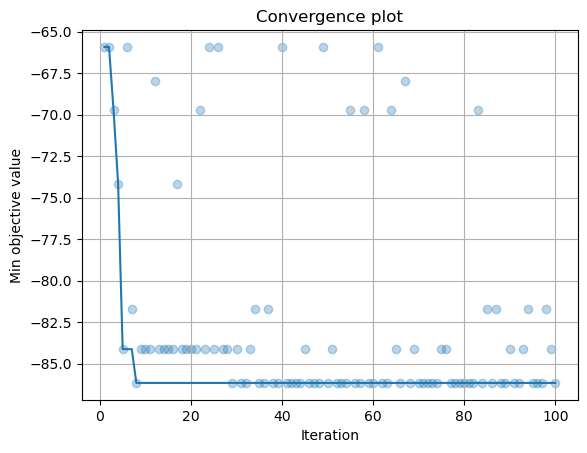

In [33]:
import matplotlib.pyplot as plt
history.plot_convergence()
plt.show()

In [34]:
print(history.get_importance())

+-----------+------------+
| Parameter | Importance |
+-----------+------------+
| m_C       | 0.929739   |
| t_RT1     | 0.021192   |
| T_drawH   | 0.009829   |
| m_B       | 0.002864   |
| T_methyl  | 0.001894   |
| t_RT2     | 0.001672   |
+-----------+------------+


In [35]:
history.visualize_html(open_html=True, show_importance=True,
                       verify_surrogate=True, optimizer=opt)

[2023-03-16 21:26:37,030][flow1][INFO][html_visualizer.py:462] Please open the html file to view visualization result: file:///home/z/zsl/flow/logs/history/flow1/flow1_2023-03-16-21-26-37-027373.html
[2023-03-16 21:26:37,142][flow1][INFO][html_visualizer.py:310] Verify surrogate model...
[2023-03-16 21:26:37,172][flow1][INFO][html_visualizer.py:96] Please open the html file to view visualization result: file:///home/z/zsl/flow/logs/history/flow1/flow1_2023-03-16-21-26-37-027373.html
